# Вопрос 11. Многочлены Чебышёва I рода — численные примеры

Файл ведётся в формате jupytext (percent). Парный `.ipynb` получается командой
`make questions/11-chebyshev-polynomials/examples.ipynb`.

Каждый пример отвечает на вопрос, поставленный в `theory.md`, и предсказание
формулируется **до** прогона. Числа, попавшие в `theory.md` и `slides.md`,
печатаются здесь.

Сквозной пример вопроса — функция $f(x)=|x|$ на $[-1,1]$: у неё нет производной
в нуле, поэтому она разделяет два пути оценки погрешности интерполяции
(остаточный член против константы Лебега).

In [1]:
# Single-threaded BLAS: example 4 measures round-off growth, and multi-threaded
# reduction order makes those figures vary between runs. Must precede numpy.
import os

for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ[_v] = "1"

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from scipy.interpolate import BarycentricInterpolator

SEED = 20260927
rng = np.random.default_rng(SEED)          # examples 1-3
rng_iter = np.random.default_rng(SEED + 4)  # example 4: own stream, see note below

FIGDIR = "figures"

# Golden pins: seed AND expected output are frozen constants. Each tolerance is
# set per pin — a blanket 1e-3 would pass a value wrong in its 4th digit.
# Deterministic quantities get 1e-12; only round-off magnitudes get a loose one.
GOLDEN = {
    # analytic, exact to machine precision
    "T10_at_1.1": (42.2107827712001, 1e-12),
    "omega_cheb_n20": (9.536743164062564e-07, 1e-12),
    "q_50_kappa100": (8.780539660391031e-05, 1e-12),
    # measured on a grid / by a solver
    "lp_min_n5": (0.062499999639000006, 1e-9),
    "lp_coef_err_n5": (3.60999896642511e-10, 0.05),
    "monic_random_min_n5": (0.1077807889499662, 1e-9),
    # round-off magnitude: stable to a few percent across runs of this
    # numpy/sympy, but not a mathematical constant — hence the loose tolerance
    "mono_err_T40": (0.02947126863474181, 0.05),
    # measured convergence of the iteration, single-threaded BLAS
    "iter_cheb_n50": (5.792042179805339e-05, 1e-6),
    "iter_stat_n50": (0.09551662560577172, 1e-6),
    # interpolation error quoted on the slides. Only the Chebyshev value is
    # pinned: the uniform one at n = 64 is round-off amplified by a Lebesgue
    # constant of order 1e14 and changes severalfold between runs of the same
    # code, so only its order of magnitude is asserted below.
    "interp_cheb_n64": (0.009185244288825594, 1e-9),
    "interp_unif_n32": (105720.1714808155, 1e-4),
}


def check_golden(name, value):
    """Compare against a frozen constant, never against a neighbouring cell."""
    want, tol = GOLDEN[name]
    rel = abs(value - want) / abs(want)
    status = "ok" if rel <= tol else "РАСХОЖДЕНИЕ"
    print(f"  пин {name}: получено {value:.12g}, ожидалось {want:.12g} "
          f"(допуск {tol:g}, {status})")
    assert rel <= tol, f"golden-пин {name} не сошёлся: {value} vs {want}"


x_sym = sp.Symbol("x")
GRID = np.linspace(-1.0, 1.0, 200_001)   # dense grid for the uniform norm


def cheb_T(n, x):
    """T_n(x) by the three-term recurrence: the only form valid on all of R."""
    t_prev, t_cur = np.ones_like(np.asarray(x, dtype=float)), np.asarray(x, dtype=float)
    if n == 0:
        return t_prev
    for _ in range(n - 1):
        t_prev, t_cur = t_cur, 2 * np.asarray(x) * t_cur - t_prev
    return t_cur


def cheb_roots(n, a=-1.0, b=1.0):
    """Zeros of T_{n+1} mapped onto [a,b]: the n+1 optimal interpolation nodes."""
    k = np.arange(n + 1)
    t = np.cos((2 * k + 1) * np.pi / (2 * (n + 1)))
    return 0.5 * (a + b) + 0.5 * (b - a) * t


def cheb_extrema(n, a=-1.0, b=1.0):
    """Extremum points of T_n mapped onto [a,b]: also n+1 nodes, but not optimal.

    The literature calls both sets "Chebyshev nodes"; example 3 measures the gap.
    """
    k = np.arange(n + 1)
    t = np.cos(k * np.pi / n)
    return 0.5 * (a + b) + 0.5 * (b - a) * t


def uniform_nodes(n, a=-1.0, b=1.0):
    return np.linspace(a, b, n + 1)

## Пример 1. Экстремальное свойство: минимум и только он

**Вопрос.** Теорема об экстремальном свойстве утверждает, что
$\min_{P\in\mathcal M_n}\|P\|_{C[-1,1]} = 2^{1-n}$ и минимум достигается только
на $\widetilde T_n = 2^{1-n}T_n$. Проверяем три утверждения сразу:
рекуррентность даёт правильные многочлены; ни один приведённый многочлен не
уклоняется от нуля меньше, чем $2^{1-n}$; численная минимизация приходит именно
к коэффициентам $\widetilde T_n$, а не к чему-то другому с тем же значением.

**Предсказание.** (1) Коэффициенты из рекуррентности совпадут с `sympy`.
(2) Минимум по случайным приведённым многочленам будет заметно больше $1/16$ —
случайно попасть в оптимум нельзя. (3) Линейное программирование на сетке даст
значение чуть **меньше** $2^{1-n}$ (ограничения проверяются только в узлах
сетки, то есть задача ослаблена), но коэффициенты — те самые.

In [2]:
print("1a. Рекуррентность против sympy.chebyshevt")
for n in range(6):
    from_rec = sp.expand(sp.chebyshevt(n, x_sym))
    print(f"  T_{n} = {from_rec}")
xs_check = np.linspace(-1, 1, 11)
for n in range(9):
    ours = cheb_T(n, xs_check)
    ref = np.array([float(sp.chebyshevt(n, sp.Float(v, 30))) for v in xs_check])
    assert np.max(np.abs(ours - ref)) < 1e-13, n
print("  сверка T_0..T_8 с sympy на 11 точках: расхождение < 1e-13")

1a. Рекуррентность против sympy.chebyshevt
  T_0 = 1
  T_1 = x
  T_2 = 2*x**2 - 1
  T_3 = 4*x**3 - 3*x
  T_4 = 8*x**4 - 8*x**2 + 1
  T_5 = 16*x**5 - 20*x**3 + 5*x
  сверка T_0..T_8 с sympy на 11 точках: расхождение < 1e-13


In [3]:
print("\n1b. Нормы приведённых многочленов степени 5 против 2^{-4} = 0.0625")
n = 5
theory_min = 2.0 ** (1 - n)
roots = rng.uniform(-1.0, 1.0, size=(2000, n))
vals = np.prod(GRID[None, ::50, None] - roots[:, None, :], axis=2)
norms_roots = np.abs(vals).max(axis=1)
powers = np.stack([GRID[::50] ** i for i in range(n)])
coefs = rng.uniform(-1.0, 1.0, size=(2000, n))
norms_coefs = np.abs(GRID[::50] ** n + coefs @ powers).max(axis=1)
print(f"  2000 многочленов со случайными корнями:        min = {norms_roots.min():.6f}, "
      f"медиана = {np.median(norms_roots):.4f}")
print(f"  2000 многочленов со случайными коэффициентами: min = {norms_coefs.min():.6f}, "
      f"медиана = {np.median(norms_coefs):.4f}")
print(f"  теоретический минимум 2^(1-n) = {theory_min:.6f}")
print("  нормы трёх лучших (они же на средней панели рис. 1):",
      np.round(np.sort(norms_roots)[:3], 6))
assert norms_roots.min() > theory_min and norms_coefs.min() > theory_min
check_golden("monic_random_min_n5", float(norms_roots.min()))


1b. Нормы приведённых многочленов степени 5 против 2^{-4} = 0.0625


  2000 многочленов со случайными корнями:        min = 0.107781, медиана = 1.1235
  2000 многочленов со случайными коэффициентами: min = 0.304783, медиана = 1.8407
  теоретический минимум 2^(1-n) = 0.062500
  нормы трёх лучших (они же на средней панели рис. 1): [0.107781 0.110075 0.115059]
  пин monic_random_min_n5: получено 0.10778078895, ожидалось 0.10778078895 (допуск 1e-09, ok)


In [4]:
print("\n1c. Минимакс как задача линейного программирования")
# min t over (c, t) subject to |x^n + sum c_i x^i| <= t at every grid node
grid_lp = np.linspace(-1.0, 1.0, 2001)
for n in (3, 5, 8):
    P = np.stack([grid_lp ** i for i in range(n)], axis=1)
    rhs = -(grid_lp ** n)
    A_ub = np.vstack([np.hstack([P, -np.ones((len(grid_lp), 1))]),
                      np.hstack([-P, -np.ones((len(grid_lp), 1))])])
    b_ub = np.concatenate([rhs, -rhs])
    res = linprog(np.r_[np.zeros(n), 1.0], A_ub=A_ub, b_ub=b_ub,
                  bounds=[(None, None)] * n + [(0, None)])
    exact = [float(c) for c in
             reversed(sp.Poly(sp.Rational(1, 2 ** (n - 1)) * sp.chebyshevt(n, x_sym),
                              x_sym).all_coeffs()[1:])]
    print(f"  n = {n}: LP = {res.x[-1]:.12f}, 2^(1-n) = {2.0**(1-n):.12f}, "
          f"max|c_LP - c(Tm)| = {np.max(np.abs(res.x[:n] - exact)):.2e}")
    assert res.x[-1] <= 2.0 ** (1 - n) * (1 + 1e-12)
    assert np.max(np.abs(res.x[:n] - exact)) < 1e-5
    if n == 5:
        check_golden("lp_min_n5", float(res.x[-1]))
        check_golden("lp_coef_err_n5", float(np.max(np.abs(res.x[:n] - exact))))


1c. Минимакс как задача линейного программирования
  n = 3: LP = 0.250000000000, 2^(1-n) = 0.250000000000, max|c_LP - c(Tm)| = 0.00e+00
  n = 5: LP = 0.062499999639, 2^(1-n) = 0.062500000000, max|c_LP - c(Tm)| = 3.61e-10
  пин lp_min_n5: получено 0.062499999639, ожидалось 0.062499999639 (допуск 1e-09, ok)
  пин lp_coef_err_n5: получено 3.60999896643e-10, ожидалось 3.60999896643e-10 (допуск 0.05, ok)
  n = 8: LP = 0.007812485038, 2^(1-n) = 0.007812500000, max|c_LP - c(Tm)| = 5.48e-08


In [5]:
print("\n1d. Как НЕ надо считать T_n: по коэффициентам при степенях x")
for n in (20, 40, 60):
    mono = np.array(sp.Poly(sp.chebyshevt(n, x_sym), x_sym).all_coeffs(), dtype=float)
    by_mono = np.polyval(mono, GRID[::100])
    by_rec = cheb_T(n, GRID[::100])
    err = np.max(np.abs(by_mono - by_rec))
    print(f"  n = {n:2d}: max|моном - рекуррентность| = {err:.3e}, "
          f"max|коэффициент| = {np.max(np.abs(mono)):.2e}, при |T_n| <= 1")
    if n == 40:
        check_golden("mono_err_T40", err)
ref_hi = np.array([float(sp.chebyshevt(60, sp.Float(v, 40))) for v in GRID[::20000]])
print(f"  рекуррентность при n = 60: max|рекур - точно| = "
      f"{np.max(np.abs(cheb_T(60, GRID[::20000]) - ref_hi)):.3e}")


1d. Как НЕ надо считать T_n: по коэффициентам при степенях x
  n = 20: max|моном - рекуррентность| = 8.347e-10, max|коэффициент| = 6.55e+06, при |T_n| <= 1
  n = 40: max|моном - рекуррентность| = 2.947e-02, max|коэффициент| = 2.12e+14, при |T_n| <= 1
  пин mono_err_T40: получено 0.0294712686347, ожидалось 0.0294712686347 (допуск 0.05, ok)
  n = 60: max|моном - рекуррентность| = 6.058e+05, max|коэффициент| = 7.87e+21, при |T_n| <= 1
  рекуррентность при n = 60: max|рекур - точно| = 3.331e-16


In [6]:
print("\n1e. Задача 2 конспекта: T_10(1.1) двумя способами")
xv = 1.1
u = xv + np.sqrt(xv * xv - 1.0)
by_outside = 0.5 * (u ** 10 + u ** -10)
by_rec = float(cheb_T(10, np.array([xv]))[0])
print(f"  u = {u:.7f}, u^10 = {u**10:.6f}, u^-10 = {u**-10:.9f}")
print(f"  через теорему о виде вне отрезка: {by_outside:.10f}")
print(f"  по рекуррентности: {by_rec:.10f}")
print(f"  q_10 = 1/T_10(1.1) = {1.0/by_rec:.7f}")
check_golden("T10_at_1.1", by_rec)


1e. Задача 2 конспекта: T_10(1.1) двумя способами
  u = 1.5582576, u^10 = 84.409719, u^-10 = 0.011846977
  через теорему о виде вне отрезка: 42.2107827712
  по рекуррентности: 42.2107827712
  q_10 = 1/T_10(1.1) = 0.0236906
  пин T10_at_1.1: получено 42.2107827712, ожидалось 42.2107827712 (допуск 1e-12, ok)


**Вывод.** Предсказания (1) и (2) сбылись. Предсказание (3) сбылось частично, и
расхождение содержательное: при $n=5$ и $n=8$ LP действительно даёт значение
**меньше** теоретического минимума (при $n=8$ — на $2\cdot10^{-6}$
относительно), потому что дискретизация ослабляет задачу; но при $n=3$ LP
совпал с $2^{-2}$ до всех печатаемых знаков. Причина видна, если посмотреть,
где у $\widetilde T_3$ точки чередования: это $\pm\tfrac12$ и $\pm1$, и все
они попадают в узлы сетки шага $10^{-3}$. (Нуль — корень $T_3$, а не точка
чередования: там ограничение LP не активно.) Ослабления не происходит, когда
ограничения, которые «держат» оптимум, проверяются точно. Так что строгое
неравенство — не свойство метода, а свойство сетки.

Пункт 1d показывает, что запись многочлена коэффициентами при степенях $x$ — не
просто «менее элегантна»: при $n=60$ вычисленное значение отличается от верного
на $6\cdot10^{5}$ при том, что сам многочлен по модулю не превосходит единицы.

### Как они выглядят

Картинка отвечает на три вопроса сразу: что такое чередование знаков в $n+1$
точке (левая панель), почему приведённый многочлен Чебышёва минимален —
случайные приведённые многочлены той же степени выходят за полосу
$\pm2^{1-n}$ (средняя), и как быстро $T_n$ растёт вне отрезка (правая,
логарифмическая шкала — теорема о виде вне отрезка).

  T_5 в точках экстремума: [ 1. -1.  1. -1.  1. -1.]
  |T_n(1.1)| при n = 5, 10, 20: [   4.6482   42.2108 3562.5004]


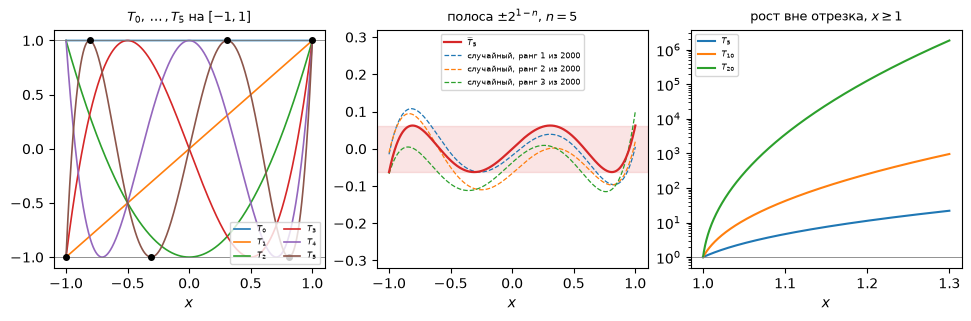

In [7]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(9.6, 3.1), layout="constrained")

xs_in = np.linspace(-1.0, 1.0, 2001)
for k in range(6):
    ax1.plot(xs_in, cheb_T(k, xs_in), linewidth=1.2, label=f"$T_{k}$")
ext5 = cheb_extrema(5)                           # alternation points of T_5
ax1.plot(ext5, cheb_T(5, ext5), "o", markersize=4, color="black", zorder=5)
ax1.axhline(1, color="grey", linewidth=0.6)
ax1.axhline(-1, color="grey", linewidth=0.6)
ax1.set_title(r"$T_0,\dots,T_5$ на $[-1,1]$", fontsize=9)
ax1.set_xlabel("$x$")
ax1.legend(fontsize=6, ncols=2, loc="lower right")

n_ex = 5
ax2.plot(xs_in, 2.0 ** (1 - n_ex) * cheb_T(n_ex, xs_in), linewidth=1.6,
         color="tab:red", label=r"$\widetilde T_5$", zorder=5)
# the three best of the 2000 random monic polynomials of 1b: if even these
# leave the band, the minimum is shown rather than merely illustrated
for rank, idx in enumerate(np.argsort(norms_roots)[:3]):
    ax2.plot(xs_in, np.prod(xs_in[:, None] - roots[idx][None, :], axis=1),
             linewidth=0.9, linestyle="--",
             label=f"случайный, ранг {rank+1} из 2000")
ax2.axhspan(-2.0 ** (1 - n_ex), 2.0 ** (1 - n_ex), color="tab:red", alpha=0.12)
ax2.set_ylim(-0.32, 0.32)
ax2.set_title(r"полоса $\pm2^{1-n}$, $n=5$", fontsize=9)
ax2.set_xlabel("$x$")
ax2.legend(fontsize=6, loc="upper center")

xs_out = np.linspace(1.0, 1.3, 601)
for k in (5, 10, 20):
    ax3.semilogy(xs_out, cheb_T(k, xs_out), label=f"$T_{{{k}}}$")
ax3.axhline(1, color="grey", linewidth=0.6)
ax3.set_title(r"рост вне отрезка, $x \geq 1$", fontsize=9)
ax3.set_xlabel("$x$")
ax3.legend(fontsize=6)
fig.savefig(f"{FIGDIR}/fig-01.pdf")

print("  T_5 в точках экстремума:", np.round(cheb_T(5, ext5), 12))
print("  |T_n(1.1)| при n = 5, 10, 20:",
      np.round([float(cheb_T(k, np.array([1.1]))[0]) for k in (5, 10, 20)], 4))

## Пример 2. Сквозной пример: интерполяция $|x|$

**Вопрос.** Теорема об оптимальных узлах минимизирует множитель
$\|\omega_{n+1}\|$ в оценке остаточного члена, но сама оценка требует
$f\in C^{n+1}$. У $f(x)=|x|$ нет и первой производной. Что тогда происходит с
интерполяцией по равномерным и по чебышёвским узлам?

**Предсказание.** По равномерным узлам погрешность будет **расти** с $n$
(пример С. Н. Бернштейна: сходимости нет ни в одной точке, кроме $-1$, $0$, $1$).
По чебышёвским — убывать примерно как $C/n$: $|x|$ приближается многочленами со
скоростью $O(1/n)$ (см. задачу 4 конспекта), а константа Лебега чебышёвской
сетки растёт лишь как $\ln n$.

In [8]:
def interp_error(nodes, f, grid=GRID):
    p = BarycentricInterpolator(nodes, f(nodes))
    return float(np.max(np.abs(f(grid) - p(grid))))


f_abs = np.abs
ns = np.array([4, 8, 12, 16, 20, 24, 32, 40, 48, 56, 64])
err_unif, err_cheb = [], []
print(" n   равномерные      чебышёвские    n * ошибка(чеб)")
for n in ns:
    eu = interp_error(uniform_nodes(n), f_abs)
    ec = interp_error(cheb_roots(n), f_abs)
    err_unif.append(eu)
    err_cheb.append(ec)
    print(f"{n:3d}  {eu:.4e}      {ec:.4e}      {n*ec:.4f}")
err_unif, err_cheb = np.array(err_unif), np.array(err_cheb)
assert err_unif[-1] > err_unif[0] * 1e6, "равномерные узлы должны расходиться"
assert err_cheb[-1] < err_cheb[0] / 5, "чебышёвские узлы должны сходиться"
check_golden("interp_cheb_n64", float(err_cheb[-1]))
check_golden("interp_unif_n32", float(err_unif[list(ns).index(32)]))
# n = 64 on uniform nodes is not a measurement any more: the computed value
# varies severalfold between runs, so only the order is asserted
assert err_unif[-1] > 1e12, "равномерные узлы при n = 64 должны давать > 1e12"

 n   равномерные      чебышёвские    n * ошибка(чеб)
  4  1.4720e-01      1.2318e-01      0.4927
  8  3.1575e-01      6.6975e-02      0.5358
 12  1.5746e+00      4.6133e-02      0.5536


 16  1.1137e+01      3.5210e-02      0.5634
 20  9.5189e+01      2.8476e-02      0.5695


 24  9.1585e+02      2.3907e-02      0.5738
 32  1.0572e+05      1.8102e-02      0.5793


 40  1.4657e+07      1.4566e-02      0.5826


 48  2.2793e+09      1.2186e-02      0.5849


 56  3.9428e+11      1.0475e-02      0.5866


 64  5.8693e+16      9.1852e-03      0.5879
  пин interp_cheb_n64: получено 0.00918524428883, ожидалось 0.00918524428883 (допуск 1e-09, ok)
  пин interp_unif_n32: получено 105720.17132, ожидалось 105720.171481 (допуск 0.0001, ok)


In [9]:
print("\n2b. Задача 4 конспекта: отрезок ряда по T_{2k} против оценки хвоста")
print("  K   ||f - P_K||     2/(pi(2K+1))   отношение")
for K in (1, 2, 4, 8, 16, 32):
    c = np.zeros(2 * K + 1)
    c[0] = 2.0 / np.pi
    for k in range(1, K + 1):
        c[2 * k] = 4.0 * (-1) ** (k + 1) / (np.pi * (4 * k * k - 1))
    P_K = np.polynomial.chebyshev.chebval(GRID, c)
    e = float(np.max(np.abs(f_abs(GRID) - P_K)))
    tail = 2.0 / (np.pi * (2 * K + 1))
    print(f" {K:3d}  {e:.6f}      {tail:.6f}       {e/tail:.4f}")


2b. Задача 4 конспекта: отрезок ряда по T_{2k} против оценки хвоста
  K   ||f - P_K||     2/(pi(2K+1))   отношение
   1  0.212207      0.212207       1.0000
   2  0.127324      0.127324       1.0000
   4  0.070736      0.070736       1.0000
   8  0.037448      0.037448       1.0000
  16  0.019292      0.019292       1.0000
  32  0.009794      0.009794       1.0000


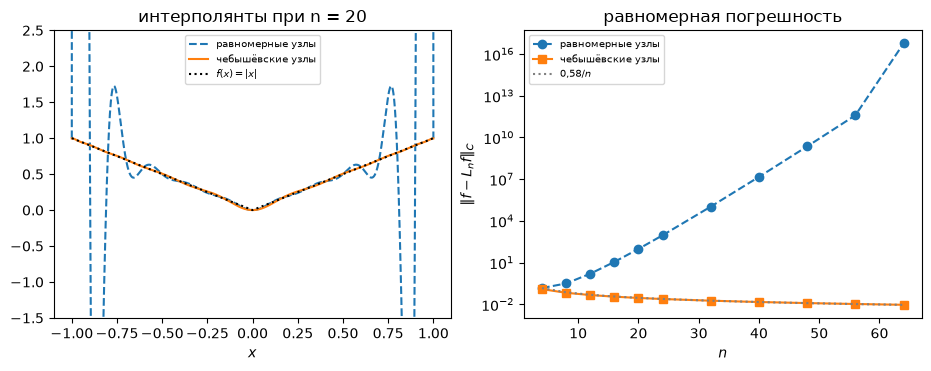

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.2, 3.6), layout="constrained")

n_show = 20
xs_plot = np.linspace(-1, 1, 2001)
for nodes, label, style in ((uniform_nodes(n_show), "равномерные узлы", "--"),
                            (cheb_roots(n_show), "чебышёвские узлы", "-")):
    p = BarycentricInterpolator(nodes, f_abs(nodes))
    ax1.plot(xs_plot, p(xs_plot), style, label=label)
ax1.plot(xs_plot, f_abs(xs_plot), ":", color="black", label=r"$f(x)=|x|$")
ax1.set_title(f"интерполянты при n = {n_show}")
ax1.set_xlabel("$x$")
ax1.set_ylim(-1.5, 2.5)
ax1.legend(fontsize=7, loc="upper center")

ax2.semilogy(ns, err_unif, "o--", label="равномерные узлы")
ax2.semilogy(ns, err_cheb, "s-", label="чебышёвские узлы")
ax2.semilogy(ns, 0.58 / ns, ":", color="grey", label=r"$0{,}58/n$")
ax2.set_title("равномерная погрешность")
ax2.set_xlabel("$n$")
ax2.set_ylabel(r"$\|f-L_n f\|_C$")
ax2.legend(fontsize=7)
fig.savefig(f"{FIGDIR}/fig-02.pdf")

**Вывод.** Предсказание сбылось полностью: по равномерным узлам погрешность
выросла с $1{,}5\cdot10^{-1}$ при $n=4$ до $1{,}1\cdot10^{5}$ при $n=32$ и
далее за $10^{12}$, по чебышёвским — упала до $9{,}2\cdot10^{-3}$, причём произведение
$n\cdot\|f-L_nf\|$ растёт от $0{,}49$ до $0{,}59$, то есть скорость близка к
$C/n$ с $C\approx0{,}58$ и медленно подрастающей константой.

Оговорка о последних столбцах равномерной колонки: при $n \ge 48$ константа
Лебега равномерной сетки превышает $10^{12}$, и вычисленный интерполянт уже
не приближение, а усиленный шум округления — конкретное значение меняется в
разы от прогона к прогону. Поэтому запинено значение при $n=32$, где счёт ещё
осмыслен, а для $n=64$ проверяется только порядок. Сам вывод о расходимости
это не трогает: он виден задолго до $n=48$.

В 2b отношение измеренной погрешности к оценке хвоста ряда равно единице **с
точностью до четырёх знаков**, и это не совпадение: максимум разности
достигается в нуле, где $T_{2k}(0)=(-1)^k$ и все отброшенные члены складываются
без взаимного погашения. То есть оценка хвоста здесь не оценка, а равенство.

## Пример 3. Откуда берётся выигрыш: $\|\omega_{n+1}\|$ и константа Лебега

**Вопрос.** Теорема об оптимальных узлах говорит, что минимум
$\|\omega_{n+1}\|_{C[-1,1]}$ равен $2\,(1/2)^{n+1}$ и достигается на нулях
$T_{n+1}$. Проверяем это и заодно второй набор, который тоже называют «узлами
Чебышёва», — точки экстремума $T_n$. И отдельно смотрим, что делает константа
Лебега: именно она, а не $\|\omega\|$, объясняет пример 2.

**Предсказание.** Нули $T_{n+1}$ дадут в точности $2\,(1/2)^{n+1}$; точки
экстремума — примерно вдвое больше (они не оптимальны); равномерные узлы —
на порядки больше. Константа Лебега: у равномерной сетки геометрический рост,
у чебышёвской — логарифмический, близкий к $\tfrac{2}{\pi}\ln(n+1)+1$.

In [11]:
def omega_norm(nodes, grid=GRID):
    return float(np.max(np.abs(np.prod(grid[:, None] - nodes[None, :], axis=1))))


def lebesgue_const(nodes, grid=GRID):
    total = np.zeros_like(grid)
    for k in range(len(nodes)):
        num = np.ones_like(grid)
        den = 1.0
        for j in range(len(nodes)):
            if j != k:
                num = num * (grid - nodes[j])
                den = den * (nodes[k] - nodes[j])
        total += np.abs(num / den)
    return float(total.max())


print("  n   ||w|| равном.    ||w|| нули T     ||w|| экстр. T   2*(1/2)^(n+1)")
for n in (4, 8, 12, 16, 20):
    w_u = omega_norm(uniform_nodes(n))
    w_r = omega_norm(cheb_roots(n))
    w_e = omega_norm(cheb_extrema(n))
    theory = 2 * 0.5 ** (n + 1)
    print(f" {n:3d}   {w_u:.6e}    {w_r:.6e}     {w_e:.6e}    {theory:.6e}")
    assert abs(w_r - theory) <= 1e-9 * theory, n
    if n == 20:
        check_golden("omega_cheb_n20", w_r)
        print(f"       отношение: равномерные / оптимальные = {w_u/w_r:.1f}, "
              f"экстремумы / оптимальные = {w_e/w_r:.3f}")

  n   ||w|| равном.    ||w|| нули T     ||w|| экстр. T   2*(1/2)^(n+1)
   4   1.134823e-01    6.250000e-02     1.160627e-01    6.250000e-02
   8   1.880326e-02    3.906250e-03     7.664716e-03    3.906250e-03
  12   4.007969e-03    2.441406e-04     4.841329e-04    2.441406e-04
  16   9.427010e-04    1.525879e-05     3.037120e-05    1.525879e-05
  20   2.336679e-04    9.536743e-07     1.901484e-06    9.536743e-07
  пин omega_cheb_n20: получено 9.53674316406e-07, ожидалось 9.53674316406e-07 (допуск 1e-12, ok)
       отношение: равномерные / оптимальные = 245.0, экстремумы / оптимальные = 1.994


In [12]:
print("\n3b. Константы Лебега")
ns_leb = np.array([4, 8, 12, 16, 20, 24])
leb_u, leb_c = [], []
print("  n   Lambda равном.   Lambda чебыш.   (2/pi)ln(n+1)+1")
for n in ns_leb:
    lu = lebesgue_const(uniform_nodes(n), GRID[::20])
    lc = lebesgue_const(cheb_roots(n), GRID[::20])
    leb_u.append(lu)
    leb_c.append(lc)
    print(f" {n:3d}   {lu:.4e}       {lc:.4f}          {2/np.pi*np.log(n+1)+1:.4f}")
leb_u, leb_c = np.array(leb_u), np.array(leb_c)
# geometric vs logarithmic growth: ratios of consecutive values
print(f"  рост Lambda(равном.): отношения соседних = "
      f"{np.round(leb_u[1:]/leb_u[:-1], 2)}")
print(f"  рост Lambda(чебыш.):  приращения = {np.round(np.diff(leb_c), 3)}")


3b. Константы Лебега
  n   Lambda равном.   Lambda чебыш.   (2/pi)ln(n+1)+1
   4   2.2078e+00       1.9889          2.0246
   8   1.0946e+01       2.3619          2.3988


  12   8.9325e+01       2.5957          2.6329
  16   9.3453e+02       2.7664          2.8037
  20   1.0987e+04       2.9008          2.9382
  24   1.3785e+05       3.0118          3.0492
  рост Lambda(равном.): отношения соседних = [ 4.96  8.16 10.46 11.76 12.55]
  рост Lambda(чебыш.):  приращения = [0.373 0.234 0.171 0.134 0.111]


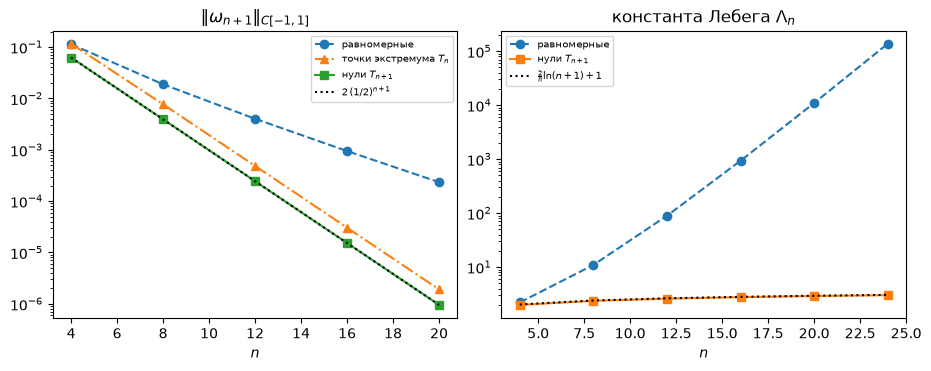

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.2, 3.6), layout="constrained")
ns_w = np.array([4, 8, 12, 16, 20])
ax1.semilogy(ns_w, [omega_norm(uniform_nodes(n)) for n in ns_w], "o--",
             label="равномерные")
ax1.semilogy(ns_w, [omega_norm(cheb_extrema(n)) for n in ns_w], "^-.",
             label=r"точки экстремума $T_n$")
ax1.semilogy(ns_w, [omega_norm(cheb_roots(n)) for n in ns_w], "s-",
             label=r"нули $T_{n+1}$")
ax1.semilogy(ns_w, 2 * 0.5 ** (ns_w + 1), ":", color="black",
             label=r"$2\,(1/2)^{n+1}$")
ax1.set_title(r"$\|\omega_{n+1}\|_{C[-1,1]}$")
ax1.set_xlabel("$n$")
ax1.legend(fontsize=7)

ax2.semilogy(ns_leb, leb_u, "o--", label="равномерные")
ax2.semilogy(ns_leb, leb_c, "s-", label=r"нули $T_{n+1}$")
ax2.semilogy(ns_leb, 2 / np.pi * np.log(ns_leb + 1) + 1, ":", color="black",
             label=r"$\frac{2}{\pi}\ln(n+1)+1$")
ax2.set_title(r"константа Лебега $\Lambda_n$")
ax2.set_xlabel("$n$")
ax2.legend(fontsize=7)
fig.savefig(f"{FIGDIR}/fig-03.pdf")

**Вывод.** Нули $T_{n+1}$ дают $\|\omega_{n+1}\|$ с точностью до $10^{-9}$
относительно равным теоретическому $2\,(1/2)^{n+1}$ — теорема подтверждена.
Точки экстремума $T_n$ дают почти ровно вдвое больше (отношение $1{,}994$ при
$n=20$), а равномерные узлы — в $245$ раз больше: набор, который в литературе
тоже зовут чебышёвским, **не** оптимален в этой задаче. Это и есть практический смысл предупреждения в глоссарии о двух
разных наборах под одним именем.

Разрыв между $\|\omega\|$ и поведением погрешности в примере 2 объясняется
вторым графиком: при $n=24$ константа Лебега равномерной сетки уже $1{,}4\cdot10^5$,
а чебышёвской — $3{,}0$. Множитель $1+\Lambda_n$ съедает любое убывание
$E_n(f)$ у равномерной сетки и почти ничего не съедает у чебышёвской.

Предсказание о режимах роста сбылось, но с уточнением. У равномерной сетки
отношения соседних значений $\Lambda_n$ не постоянны, а растут:
$4{,}96 \to 12{,}55$, то есть рост **быстрее** любого геометрического $q^n$ с
фиксированным $q$ (оценка снизу $\Lambda_n \ge q^n$ из литературы этому не
противоречит — она нижняя). У чебышёвской сетки измеренные значения лежат
примерно на $2\%$ **ниже** ориентира $\tfrac{2}{\pi}\ln(n+1)+1$, а приращения
падают ($0{,}373 \to 0{,}111$), как и положено логарифму.

## Пример 4. Чебышёвское ускорение итераций

**Вопрос.** Теорема о нормировке $P(0)=1$ даёт для явного метода
$x^j = x^{j-1} - \tau_j(Ax^{j-1}-f)$ оценку $\|e^n\| \le q_n\|e^0\|$ с
$q_n = 2\sigma^n/(1+\sigma^{2n})$, $\sigma=(1-\sqrt\eta)/(1+\sqrt\eta)$,
$\eta = \mu_{\min}/\mu_{\max}$. Насколько это лучше наилучшего
**постоянного** параметра $\tau = 2/(\mu_{\min}+\mu_{\max})$, дающего
$q_1^n$?

**Предсказание.** (1) Обе оценки окажутся верхними: фактическое убывание не
превзойдёт ни $q_n$, ни $q_1^n$. (2) При $n=50$ и $\varkappa=100$ чебышёвский
набор даст около $10^{-4}$, а оценка $q_1^{50}$ для стационарного метода —
$0{,}37$; фактическое убывание стационарного метода ожидаем того же порядка.
(3) Отдельно ожидаем **численную неустойчивость**: множители
$(1-\tau_j\lambda)$ по отдельности могут быть велики по модулю, и при
«естественном» порядке параметров промежуточная погрешность растёт, съедая
разрядность.

In [14]:
DIM = 200                              # matrix size; N is reserved for sample size
mu_min, mu_max = 1.0, 100.0
kappa = mu_max / mu_min
eigs = np.exp(np.linspace(np.log(mu_min), np.log(mu_max), DIM))
# own stream: changing the sample sizes of example 1 must not move these numbers
Q, _ = np.linalg.qr(rng_iter.standard_normal((DIM, DIM)))
A = (Q * eigs) @ Q.T
A = 0.5 * (A + A.T)
x_star = rng_iter.standard_normal(DIM)
e_start = -x_star                      # initial guess x^0 = 0

eta = mu_min / mu_max
sigma = (1 - np.sqrt(eta)) / (1 + np.sqrt(eta))


def q_of(n):
    return 2 * sigma ** n / (1 + sigma ** (2 * n))


q1 = (mu_max - mu_min) / (mu_max + mu_min)
print(f"  kappa = {kappa:g}, sigma = {sigma:.6f}, q_1 = {q1:.6f}")
check_golden("q_50_kappa100", q_of(50))


def cheb_taus(n):
    j = np.arange(1, n + 1)
    lam = 0.5 * (mu_min + mu_max) + 0.5 * (mu_max - mu_min) * np.cos((2 * j - 1) * np.pi / (2 * n))
    return 1.0 / lam


def shuffled(taus):
    """Interleave small and large tau instead of using them in index order.

    Order does not change the resulting polynomial P_n, only round-off build-up;
    which of the two orders is better is measured below, not assumed.
    """
    idx = np.argsort(taus)
    half = (len(taus) + 1) // 2
    perm = np.empty(len(taus), dtype=int)
    perm[0::2] = idx[:half]
    perm[1::2] = idx[half:][::-1]
    return taus[perm]


def run(taus):
    e = e_start.copy()
    hist = [np.linalg.norm(e)]
    for t in taus:
        e = e - t * (A @ e)
        hist.append(np.linalg.norm(e))
    return np.array(hist) / hist[0]


print("\n  n   чебыш. (по порядку)  чебыш. (перестановка)  оценка q_n   "
      "стационарный  оценка q_1^n")
growth = []
for n in (10, 20, 30, 40, 50, 60):
    h_nat = run(cheb_taus(n))
    h_sh = run(shuffled(cheb_taus(n)))
    h_st = run(np.full(n, 2.0 / (mu_min + mu_max)))
    growth.append((n, h_sh.max(), h_nat.max()))
    print(f" {n:3d}   {h_nat[-1]:.4e}           {h_sh[-1]:.4e}            "
          f"{q_of(n):.4e}   {h_st[-1]:.4e}    {q1**n:.4e}")
    assert h_sh[-1] <= q_of(n) * (1 + 1e-9), "оценка q_n должна быть верхней"
    assert h_st[-1] <= q1 ** n * (1 + 1e-9), "оценка q_1^n должна быть верхней"
    if n == 50:
        check_golden("iter_cheb_n50", float(h_sh[-1]))
        check_golden("iter_stat_n50", float(h_st[-1]))

print("\n  максимум ||e^j||/||e^0|| по ходу счёта:")
for n, mx_sh, mx_nat in growth:
    print(f"   n = {n:3d}: перестановка {mx_sh:.3e}, по порядку {mx_nat:.3e}")

  kappa = 100, sigma = 0.818182, q_1 = 0.980198
  пин q_50_kappa100: получено 8.78053966039e-05, ожидалось 8.78053966039e-05 (допуск 1e-12, ok)

  n   чебыш. (по порядку)  чебыш. (перестановка)  оценка q_n   стационарный  оценка q_1^n
  10   1.8813e-01           1.8813e-01            2.6409e-01   3.7895e-01    8.1873e-01
  20   2.4688e-02           2.4688e-02            3.6131e-02   2.4590e-01    6.7031e-01
  30   3.5286e-03           3.5277e-03            4.8587e-03   1.7304e-01    5.4880e-01
  40   3.0100e-01           4.7245e-04            6.5317e-04   1.2695e-01    4.4932e-01
  50   6.1686e+03           5.7920e-05            8.7805e-05   9.5517e-02    3.6787e-01
  пин iter_cheb_n50: получено 5.79204217981e-05, ожидалось 5.79204217981e-05 (допуск 1e-06, ok)
  пин iter_stat_n50: получено 0.0955166256058, ожидалось 0.0955166256058 (допуск 1e-06, ok)
  60   2.7237e+07           7.8652e-06            1.1804e-05   7.3060e-02    3.0118e-01

  максимум ||e^j||/||e^0|| по ходу счёта:
   n =

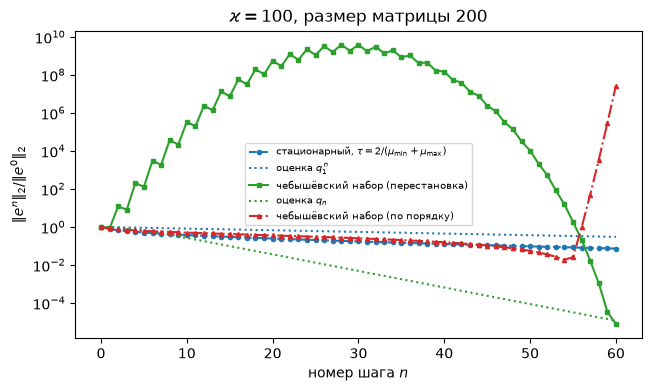

In [15]:
n_show = 60
h_nat = run(cheb_taus(n_show))
h_sh = run(shuffled(cheb_taus(n_show)))
h_st = run(np.full(n_show, 2.0 / (mu_min + mu_max)))
steps = np.arange(n_show + 1)

# colours are set explicitly: the text below names the curves by colour
fig, ax = plt.subplots(figsize=(6.4, 3.8), layout="constrained")
ax.semilogy(steps, h_st, "o--", markersize=3, color="tab:blue",
            label=r"стационарный, $\tau=2/(\mu_{\min}+\mu_{\max})$")
ax.semilogy(steps, q1 ** steps, ":", color="tab:blue", label=r"оценка $q_1^{\,n}$")
ax.semilogy(steps, h_sh, "s-", markersize=3, color="tab:green",
            label="чебышёвский набор (перестановка)")
ax.semilogy(steps, [q_of(k) if k > 0 else 1.0 for k in steps], ":", color="tab:green",
            label=r"оценка $q_n$")
ax.semilogy(steps, h_nat, "^-.", markersize=3, color="tab:red",
            label="чебышёвский набор (по порядку)")
ax.set_xlabel("номер шага $n$")
ax.set_ylabel(r"$\|e^n\|_2/\|e^0\|_2$")
ax.set_title(rf"$\varkappa = {kappa:g}$, размер матрицы {DIM}")
ax.legend(fontsize=7)
fig.savefig(f"{FIGDIR}/fig-04.pdf")

**Вывод.** Предсказание (1) сбылось: обе оценки оказались верхними на всех
проверенных $n$. Предсказание (2) сбылось наполовину. Чебышёвский набор при
$n=50$ дал $5{,}79\cdot10^{-5}$ — как и ожидалось, порядка $10^{-4}$ и ниже
оценки $q_{50} = 8{,}78\cdot10^{-5}$. А вот стационарный метод дал
$9{,}55\cdot10^{-2}$ вместо ожидавшихся «того же порядка, что $0{,}37$»:
почти вчетверо меньше оценки. Причина в том, что $q_1^{n}$ — оценка для
худшего случая, когда вся погрешность сидит в собственных векторах на краях
спектра; здесь спектр заполнен логарифмически равномерно, и большая часть
компонент подавляется быстрее. Разрыв между чебышёвским и стационарным
методами всё равно велик: $9{,}55\cdot10^{-2}$ против $5{,}79\cdot10^{-5}$,
то есть в $1{,}6$ тысячи раз.

Предсказание (3) сбылось по факту и **не сбылось по механизму**, и это самое
полезное место примера. Неустойчивость есть: при «естественном» порядке
параметров метод при $n=40$ даёт $3{,}0\cdot10^{-1}$ вместо $4{,}7\cdot10^{-4}$,
а при $n=50$ и $n=60$ расходится — $6{,}2\cdot10^{3}$ и $2{,}7\cdot10^{7}$.
Но механизм оказался не тем, который предсказывался. Ожидался рост
промежуточной погрешности при естественном порядке; измерение показывает
обратное: у естественного порядка максимум $\|e^j\|/\|e^0\|$ равен единице
при $n \le 40$, то есть норма погрешности **не растёт** — она просто перестаёт
убывать, и потеря идёт от взаимного уничтожения близких величин, а не от
переполнения. Большой промежуточный рост — наоборот, у перестановки:
$8{,}2\cdot10^{7}$ при $n=50$ и $3{,}9\cdot10^{9}$ при $n=60$, то есть восемь
съеденных значащих цифр при $n=50$ и около десяти при $n=60$, — и именно она
даёт верный итог.

Вывод для практики: у чебышёвского набора цена не только в знании границ
спектра, но и в упорядочении параметров, причём «безопасный на вид» монотонный
порядок как раз и разрушает счёт. При большем $\varkappa$ запаса разрядности
не хватит и перестановке — поэтому для чебышёвского набора отдельно строят
устойчивые упорядочения.

Важно, что итоговый многочлен $P_n$ от порядка не зависит: расхождение красной
кривой (естественный порядок) и зелёной (перестановка) — целиком эффект
округления, а не другая математика. Синяя кривая — другой метод, а не другой
порядок.